In [57]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [2]:
data=pd.read_csv("data.csv",  encoding='cp1252')
data.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Task 1**

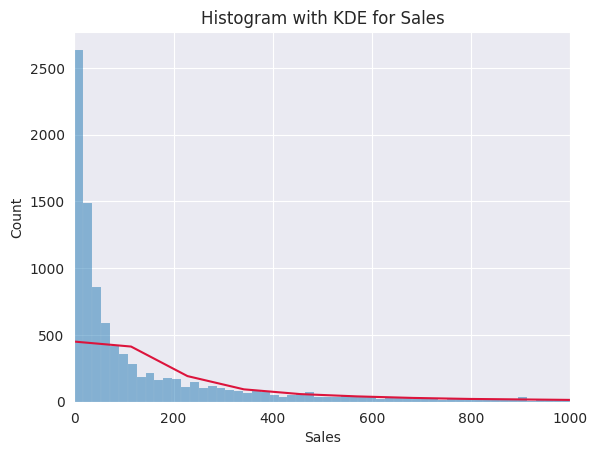

In [11]:
#plot a histogram with the KDE overlay for sales column \
sns.set_style('darkgrid')
ax=sns.histplot(data['Sales'], kde=True)
ax.lines[0].set_color("crimson")
plt.xlim(0, 1000)
plt.xlabel("Sales")
plt.ylabel("Count")
plt.title("Histogram with KDE for Sales")
plt.show()

Skewness Value, Mean and Median Comparison

In [10]:
print("Skewness: ", data['Sales'].skew())
print("Mean: ", data['Sales'].mean())
print("Median: ", data['Sales'].median())

Skewness:  12.97275234181623
Mean:  229.85800083049833
Median:  54.489999999999995


The Sales column is rightly skewed, or positively skewed. If the data is rightly skewed its Mean>Median.

**Task 2**

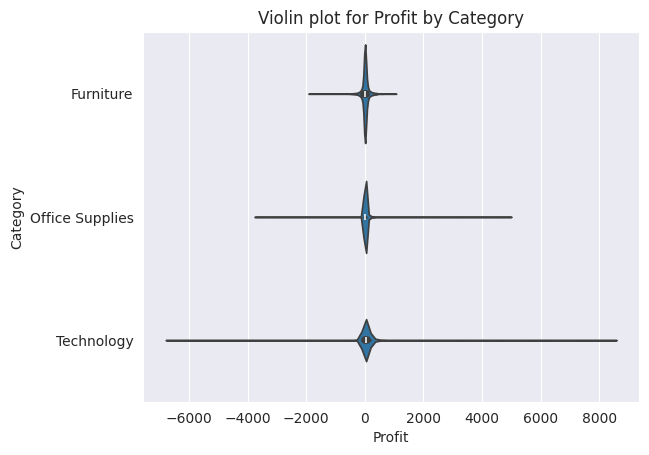

<Figure size 1200x1200 with 0 Axes>

In [15]:
sns.violinplot(data=data, x="Profit", y="Category")
plt.title("Violin plot for Profit by Category")
plt.figure(figsize=(12, 12))
plt.show()

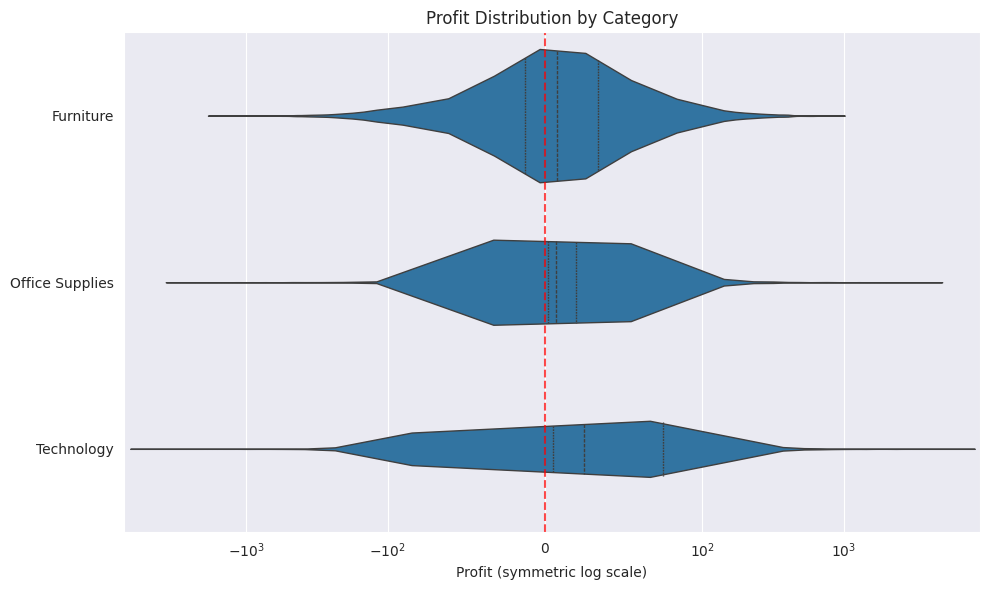

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=data,
    x="Profit",
    y="Category",
    inner="quartile",
    cut=0,
    linewidth=1,
    ax=ax
)

#since the original violin plot didnt give much info, i used symlog for x-axis which
#uses the same distances for the same multiplicative changes

ax.set_xscale("symlog", linthresh=100)
ax.axvline(0, color="red", linestyle="--", alpha=0.7)

plt.title("Profit Distribution by Category")
plt.xlabel("Profit (symmetric log scale)")
plt.ylabel("")
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Category')

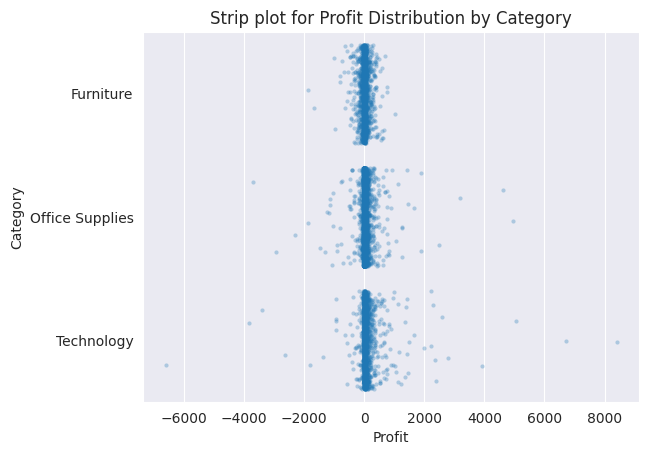

In [20]:
#jitter plot
sns.stripplot(data=data, x="Profit", y="Category", jitter=0.4, alpha=0.3, size=3)
plt.title("Strip plot for Profit Distribution by Category")
plt.xlabel("Profit")
plt.ylabel("Category")

The cateogry with bimodal distribution is technology.

**Task 3**

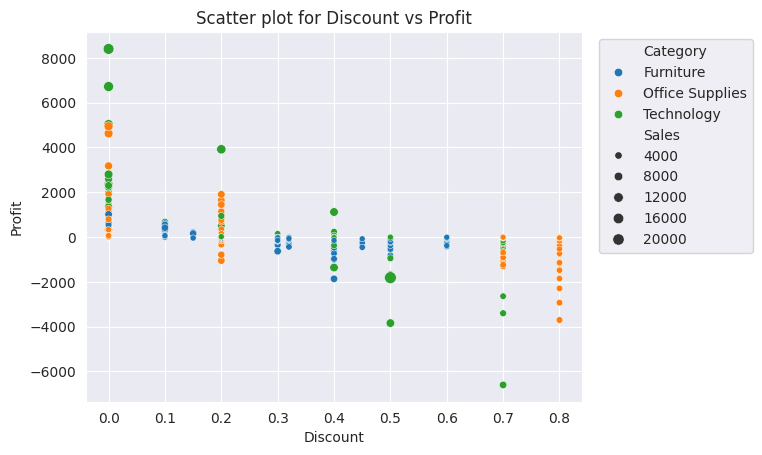

In [30]:
sns.scatterplot(data=data, x="Discount", y="Profit", hue="Category", size="Sales")
plt.title("Scatter plot for Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

as we go on to increase the discount for technology more items are sold but the company is losing profit.

**Task 4**

In [31]:
numeric_columns=["Profit", "Discount", "Sales"]
pearson_matrix = data[numeric_columns].corr(method="pearson")
spearman_matrix = data[numeric_columns].corr(method="spearman")

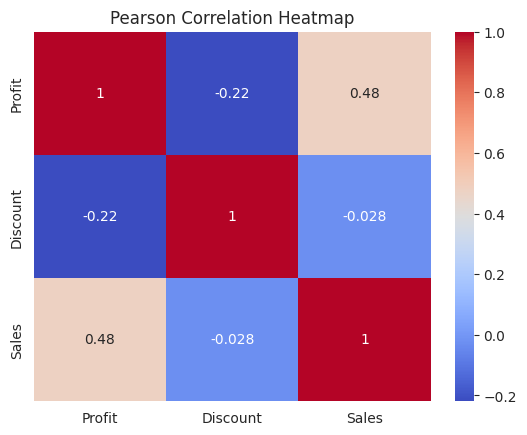

In [32]:
sns.heatmap(pearson_matrix, annot=True, cmap="coolwarm")
plt.title("Pearson Correlation Heatmap")
plt.show()


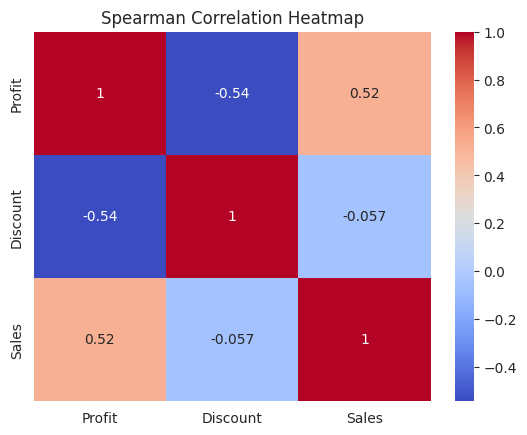

In [33]:
sns.heatmap(spearman_matrix, annot=True, cmap="coolwarm")
plt.title("Spearman Correlation Heatmap")
plt.show()

The two methods kind of disagree for Profit and Discount.

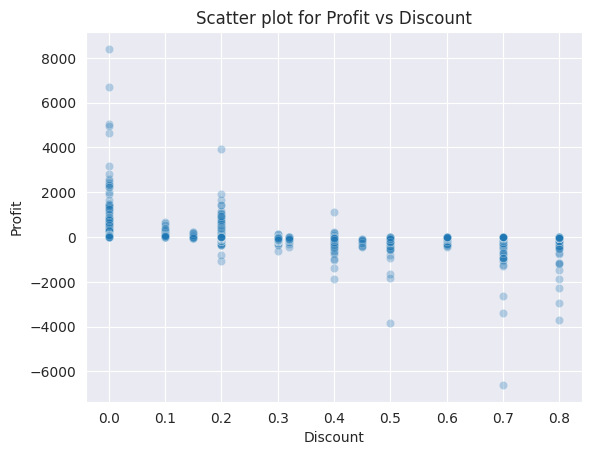

In [37]:
sns.scatterplot(data=data, x="Discount", y="Profit", alpha=0.3)
plt.title("Scatter plot for Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

Here pearsons is like more focused on numerics and sensitive to outliers, but spearman is more focused on rank, due to which theres a difference, but even if they both give a negative relation, it does not mean one causes the other

**Task 5**

In [53]:
table = pd.pivot_table(
    data,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum",
    margins=True
)
table.style \
    .format("${:,.0f}") \
    .background_gradient(cmap="Greens", axis=None) \
    .set_caption("Total Sales by Region and Category")


Category,Furniture,Office Supplies,Technology,All
Region,,,,
Central,"$163,797","$167,026","$170,416","$501,240"
East,"$208,291","$205,516","$264,974","$678,781"
South,"$117,299","$125,651","$148,772","$391,722"
West,"$252,613","$220,853","$251,992","$725,458"
All,"$742,000","$719,047","$836,154","$2,297,201"


<Axes: xlabel='Category', ylabel='Region'>

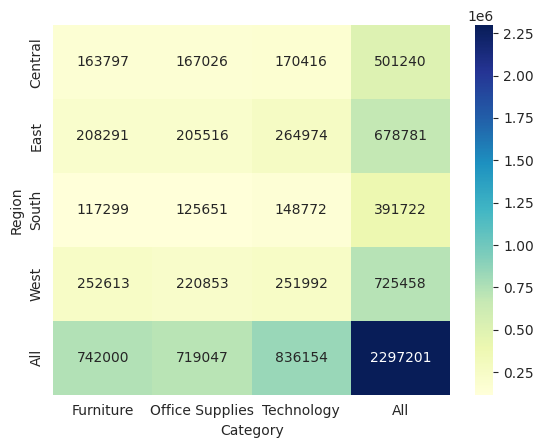

In [54]:
table=pd.DataFrame(table)
sns.heatmap(table, annot=True,  cmap="YlGnBu", fmt=".0f")


East-Technology

**Task 6**

In [58]:
#now we plot for a certain year
#imma plot for 2016
yof=2016 #year of focus

#total monthly sales summarized by month
data["Order Date"]=pd.to_datetime(data["Order Date"])
data["Year"]=data["Order Date"].dt.year
data["Month"]=data["Order Date"].dt.month
data.head(5)
#bar chart
sns.set_theme(style="darkgrid")
year_data=data[data["Year"]==yof]
#print(year_data.head(5))
#sum the sales of all months so that each month only has one row

year_data=year_data.groupby(["Month"])[["Sales", "Profit"]].sum()
year_data=year_data.reset_index()
year_data=pd.DataFrame(year_data)

#match month number to month name
year_data.head(12)
year_data["Month"] = year_data["Month"].apply(lambda x: calendar.month_name[int(x)])

print(year_data.head(12))

        Month       Sales      Profit
0     January  18542.4910   2824.8233
1    February  22978.8150   5004.5795
2       March  51715.8750   3611.9680
3       April  38750.0390   2977.8149
4         May  56987.7280   8662.1464
5        June  40344.5340   4750.3781
6        July  39261.9630   4432.8779
7      August  31115.3743   2062.0693
8   September  73410.0249   9328.6576
9     October  59687.7450  16243.1425
10   November  79411.9658   4011.4075
11   December  96999.0430  17885.3093


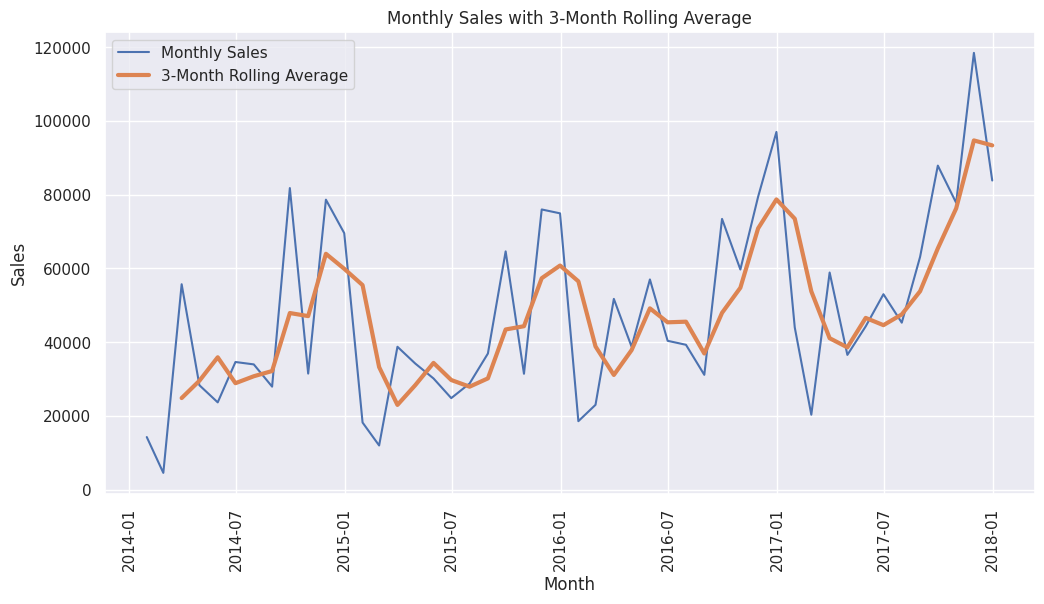

In [60]:
#Resample sales to monthly totals and overlay a 3-month rolling
#average on the same plot. In 2 sentences, describe what the rolling average reveals that the
#raw monthly line does not.

#rolling average -> average of a fix number of values
data["Order Date"]=pd.to_datetime(data["Order Date"])
monthly_sales = data.resample("ME", on="Order Date")["Sales"].sum()
rolling_3 = monthly_sales.rolling(3).mean()


data["Order Date"] = pd.to_datetime(data["Order Date"])

monthly_sales = data.resample(
    "ME",
    on="Order Date"
)["Sales"].sum()

rolling_3 = monthly_sales.rolling(3).mean()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Monthly Sales"
)

plt.plot(
    rolling_3.index,
    rolling_3.values,
    label="3-Month Rolling Average",
    linewidth=3
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title(f"Monthly Sales with 3-Month Rolling Average")
plt.xticks(rotation=90)
plt.legend()

plt.show()



it reveals a moral general growth or declin without focusing on monthly spikes

**Task 7**

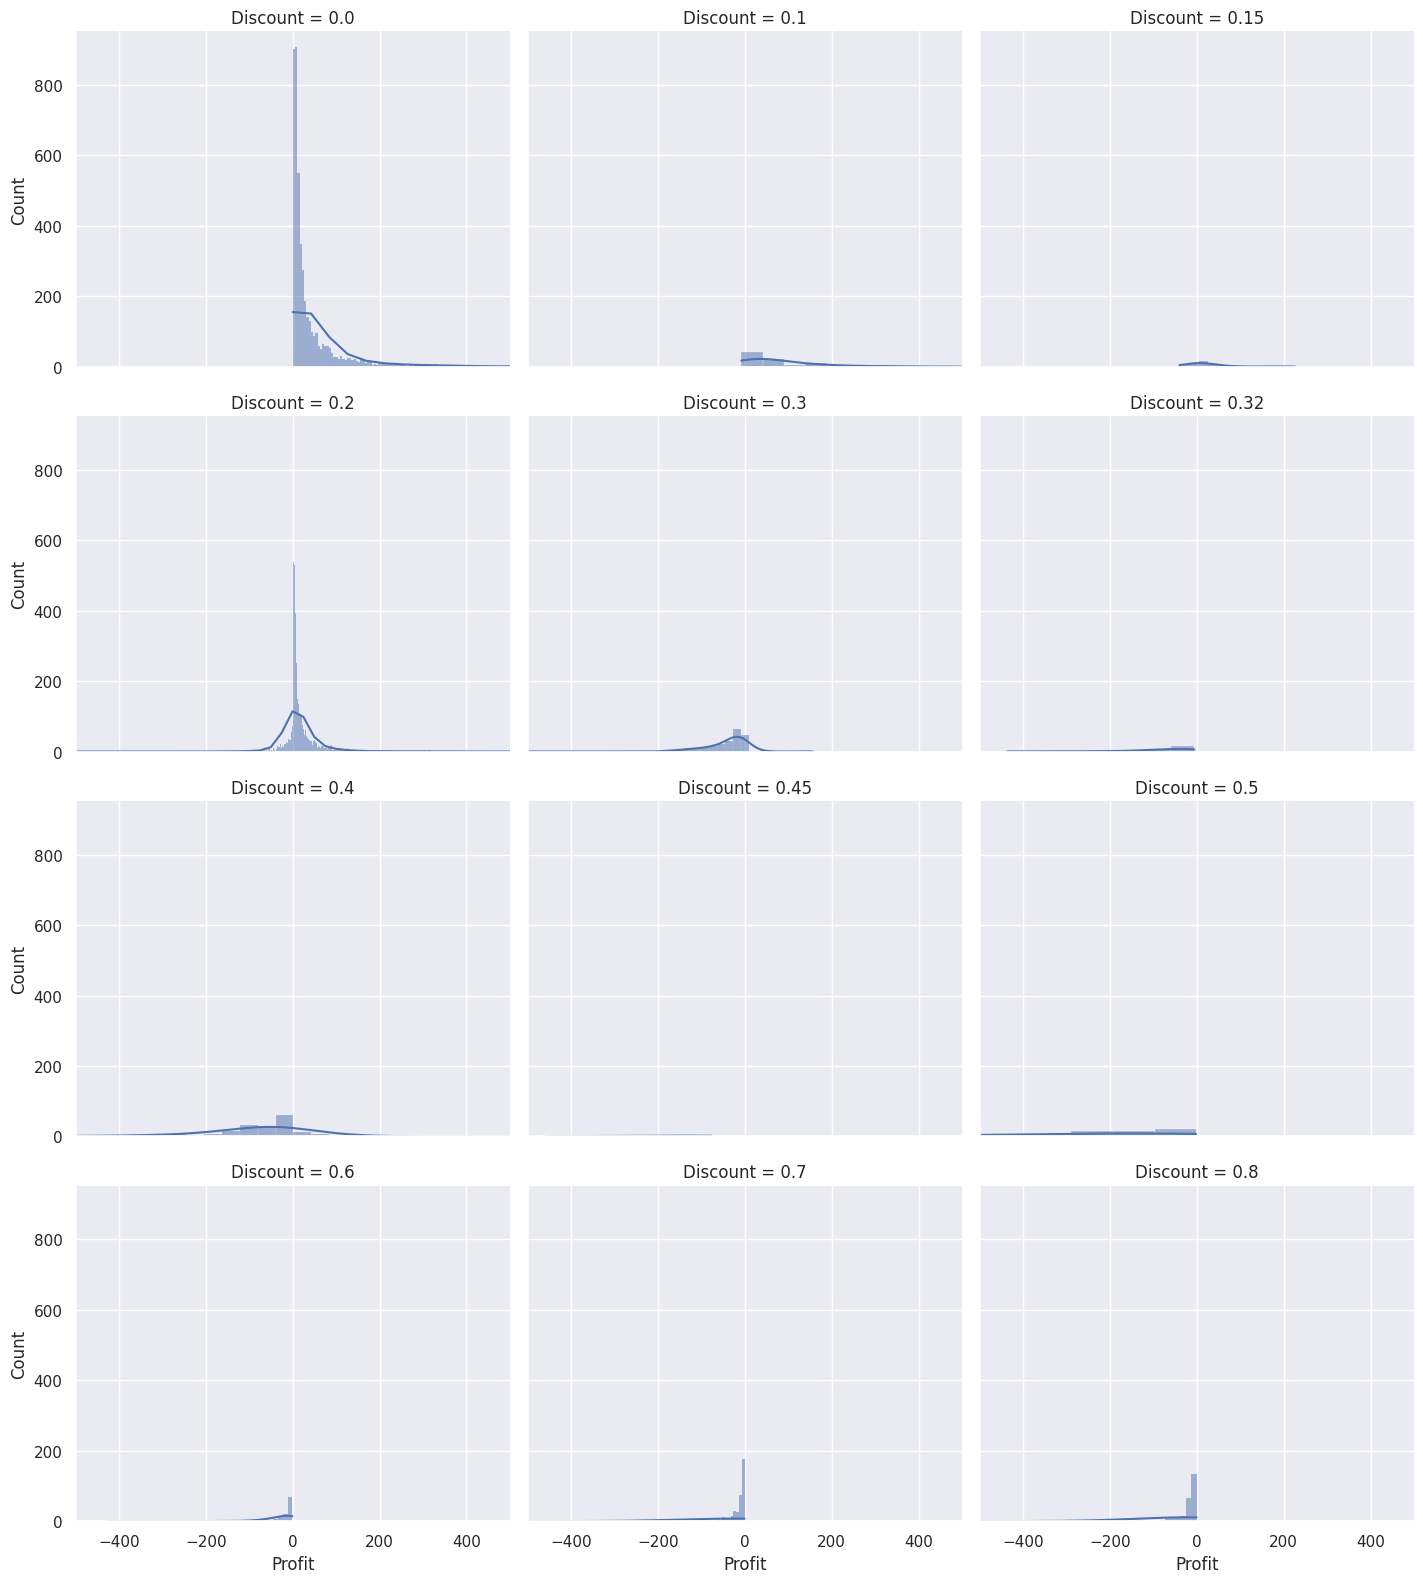

In [63]:
g=sns.FacetGrid(data, col="Discount", height=4, col_wrap=3, aspect=1.2)
g.map(sns.histplot, "Profit", kde=True)
g.set(xlim=(-500, 500))
plt.show()

For disocunt=0.0 and 0.2 are distinctivly different.

**Task 8**

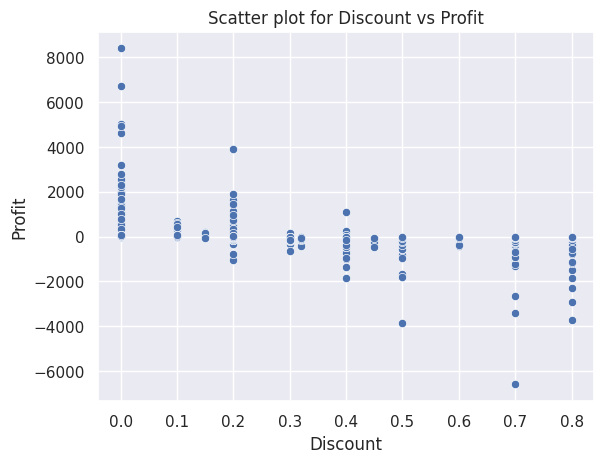

In [65]:
sns.scatterplot(data=data, x="Discount", y="Profit")
plt.title("Scatter plot for Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

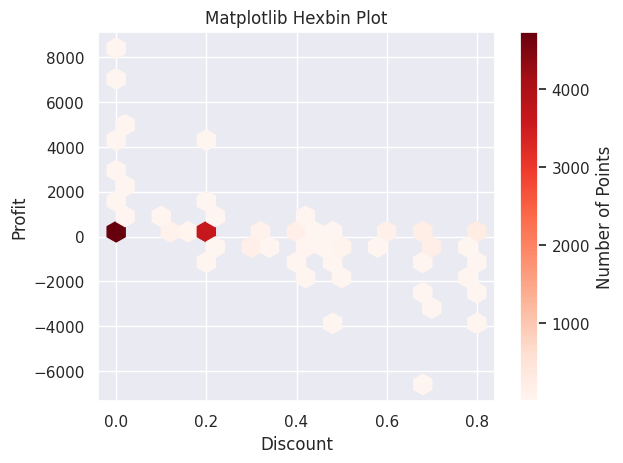

In [74]:
x=data["Discount"]
y=data["Profit"]
hb=plt.hexbin(x, y, gridsize=20, cmap='Reds', mincnt=1)
plt.colorbar(hb, label='Number of Points')

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Matplotlib Hexbin Plot')
plt.show()

I picked hex because i thought hex was cooler.

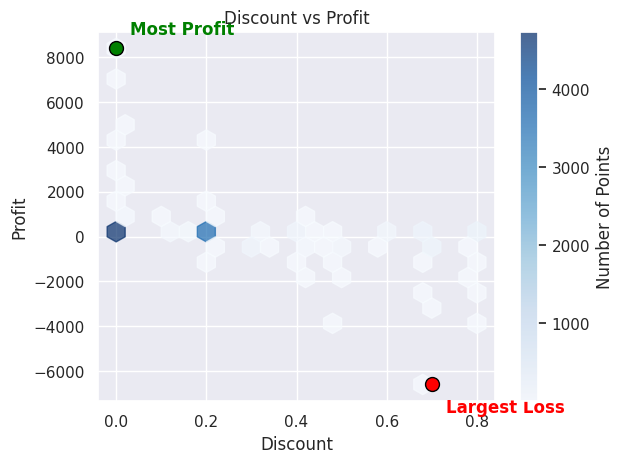

In [84]:

#norma fixed hexbin
hb = plt.hexbin(
    x,
    y,
    gridsize=20,
    cmap="Blues",
    mincnt=1,
    alpha=0.7
)
plt.colorbar(hb, label="Number of Points")
#finding the most profitable and loss
max_profit=data.loc[data["Profit"].idxmax()]
max_loss=data.loc[data["Profit"].idxmin()]

# Mark the two points
plt.scatter(
    max_profit["Discount"],
    max_profit["Profit"],
    color="green",
    s=100,
    edgecolor="black",
    zorder=5
)

plt.scatter(
    max_loss["Discount"],
    max_loss["Profit"],
    color="red",
    s=100,
    edgecolor="black",
    zorder=5
)

# Annotate most profitable order
plt.annotate(
    "Most Profit",
    (max_profit["Discount"], max_profit["Profit"]),
    xytext=(10, 10),
    textcoords="offset points",
    color="green",
    fontweight="bold"
)

# Annotate largest loss
plt.annotate(
    "Largest Loss",
    (max_loss["Discount"], max_loss["Profit"]),
    xytext=(10, -20),
    textcoords="offset points",
    color="red",
    fontweight="bold"
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()
